## Phase 1: Data Loading & Cleaning

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import ast

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist

from gensim.models import Word2Vec
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import scipy.sparse as sp
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from joblib import Parallel, delayed

from groq import Groq
import time

In [20]:
songs_df = pd.read_csv("songs.csv")
artists_df = pd.read_csv("artists.csv")

print("Songs shape:", songs_df.shape)
print("Artists shape:", artists_df.shape)
print("\nSongs columns:", songs_df.columns.tolist())
print("\nArtists columns:", artists_df.columns.tolist())

Songs shape: (550622, 24)
Artists shape: (71440, 6)

Songs columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']

Artists columns: ['id', 'name', 'followers', 'popularity', 'genres', 'main_genre']


In [21]:
cols_to_drop = ['key', 'mode', 'liveness',
                'acousticness', 'instrumentalness',
                'duration_ms', 'album_name', 'artist_ids']

songs_df = songs_df.drop(columns=cols_to_drop)  
print("Remaining columns:", songs_df.columns.tolist())

Remaining columns: ['id', 'name', 'artists', 'danceability', 'energy', 'loudness', 'speechiness', 'valence', 'tempo', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'niche_genres']


In [22]:
print(songs_df.isnull().sum())

id                        0
name                      3
artists                   0
danceability              0
energy                    0
loudness                  0
speechiness               0
valence                   0
tempo                     0
lyrics                    0
year                      0
genre                     0
popularity                0
total_artist_followers    0
avg_artist_popularity     0
niche_genres              0
dtype: int64


In [23]:
has_timestamp = songs_df['lyrics'].str.contains(
    r'\[\d{2}:\d{2}\.\d{2,3}\]', regex=True, na=False
)
print("Songs with timestamps:", has_timestamp.sum())

songs_df = songs_df[~has_timestamp]
print("Songs remaining:", len(songs_df))

Songs with timestamps: 25
Songs remaining: 550597


In [24]:
def remove_repeated_lines(text):
    lines = text.split('\n')
    cleaned = []
    previous_line = None
    for line in lines:
        line = line.strip()
        if line != previous_line and line != '':
            cleaned.append(line)
            previous_line = line
    return '\n'.join(cleaned)

songs_df['lyrics_clean'] = songs_df['lyrics'].apply(remove_repeated_lines)
print(songs_df['lyrics_clean'].iloc[0][:300])

He said he came from Jamaica,\nhe owned a couple acres A couple fake visas 'cause he never got his\npapers Gave up on love fucking with them heart breakers But he was\ngetting money with the movers and the shakers He was mixed with a\ncouple things, bald like a couple rings Bricks in the condo and g


## lyrics_normalized
Used as input to TF-IDF, NRC, VAD, and VADER.
This is `lyrics_clean` with `\n` replaced by space.

In [25]:
songs_df['lyrics_normalized'] = songs_df['lyrics_clean'].str.replace('\n', ' ')
songs_df['lyrics_normalized'] = songs_df['lyrics_clean'].str.replace('\\n', ' ')
print("Sample lyrics_normalized:")
print(songs_df['lyrics_normalized'].iloc[0][:300])

Sample lyrics_normalized:
He said he came from Jamaica, he owned a couple acres A couple fake visas 'cause he never got his papers Gave up on love fucking with them heart breakers But he was getting money with the movers and the shakers He was mixed with a couple things, bald like a couple rings Bricks in the condo and grams


In [26]:
from langdetect import detect, LangDetectException
from joblib import Parallel, delayed

def detect_language(text):
    try:
        text = str(text).replace('\\n', ' ').replace('\n', ' ')
        return detect(text[:500])
    except:
        return 'unknown'

print("Detecting languages on full dataset...")
songs_df['language'] = Parallel(n_jobs=-1)(
    delayed(detect_language)(text) for text in songs_df['lyrics']
)

print("\nLanguage distribution:")
print(songs_df['language'].value_counts().head(10))

Detecting languages on full dataset...

Language distribution:
language
en    547334
ko       721
ja       297
id       280
es       271
so       190
fr       189
tl       129
de       119
pt       118
Name: count, dtype: int64


In [27]:
songs_df = songs_df[songs_df['language'] == 'en'].copy()
print("Songs after non-English filter:", len(songs_df))
print("\nSongs columns:", songs_df.columns.tolist())
songs_df.head()


Songs after non-English filter: 547334

Songs columns: ['id', 'name', 'artists', 'danceability', 'energy', 'loudness', 'speechiness', 'valence', 'tempo', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'niche_genres', 'lyrics_clean', 'lyrics_normalized', 'language']


,id,name,artists,danceability,energy,loudness,speechiness,valence,tempo,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,niche_genres,lyrics_clean,lyrics_normalized,language
0,0Prct5TDjAnEgIqbxcldY9,!,"[""HELLYEAH""]",0.415,0.605,-11.157,0.0575,0.193,100.059,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""groove metal"", ""metal""]","He said he came from Jamaica,\nhe owned a coup...","He said he came from Jamaica, he owned a coupl...",en
1,2ASl4wirkeYm3OWZxXKYuq,!!,"[""Yxngxr1""]",0.788,0.648,-9.135,0.3150,0.287,79.998,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,[],"Fuck the bitch, now she running with my kids\n...","Fuck the bitch, now she running with my kids A...",en
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,"[""Dillinger Four""]",0.171,0.957,-5.749,0.1490,0.349,175.317,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""melodic hardcore"", ""pop punk"", ""punk"", ""skat...",You like to stand on the other side\nPoint and...,You like to stand on the other side\nPoint and...,en
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,-7.767,0.2480,0.688,142.959,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""french rap""]","It's been a while, shit, I missed the rehab, p...","It's been a while, shit, I missed the rehab, p...",en
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,-8.562,0.0650,0.380,86.103,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""french rap""]",I would like to give you all my time\nI would ...,I would like to give you all my time\nI would ...,en


In [29]:
import nltk
from nltk.corpus import words as nltk_words
nltk.download('words')

english_vocab = set(w.lower() for w in nltk_words.words())

# ── Step 1: Find gibberish words specific to YOUR dataset ──
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 1),
    min_df=100  
)

X = vectorizer.fit_transform(songs_df["lyrics_normalized"].fillna(""))
vocab = vectorizer.get_feature_names_out()
word_freq = X.sum(axis=0).A1

freq_df = pd.DataFrame({"word": vocab, "frequency": word_freq})
freq_df = freq_df.sort_values("frequency", ascending=False)

# Flag words not in English dictionary
freq_df["is_gibberish"] = ~freq_df["word"].isin(english_vocab)

print("Top 100 most frequent NON-dictionary words (likely gibberish):")
print(freq_df[freq_df["is_gibberish"]].head(700)["word"].tolist())

[nltk_data] Downloading package words to
[nltk_data]     /Users/ishitaagarwal/nltk_data...
[nltk_data]   Package words is already up-to-date!


Top 100 most frequent NON-dictionary words (likely gibberish):
['ll', 've', 'wanna', 'ain', 'gonna', 'eyes', 'ooh', 'things', 'gotta', 'fuck', 'shit', 'nigga', 'uh', 'hands', 'didn', 'words', 'niggas', 'dreams', 'friends', 'dem', 'makes', 'heard', 'lies', 'years', 'tears', 'knows', 'feels', 'stars', 'feet', 'fucking', 'lights', 'girls', 'mama', 'couldn', 'wanted', 'goodbye', 'goin', 'doesn', 'boys', 'anymore', 'gets', 'okay', 'loved', 'nothin', 'wouldn', 'takes', 'comin', 'woah', 'lives', 'tryna', 'nah', 'says', 'gettin', 'lookin', 'fuckin', 'ones', 'called', 'started', 'wasn', 'children', 'feelin', 'knees', 'lips', 'keeps', 'bitches', 'ayy', 'nuh', 'wants', 'lovin', 'thoughts', 'talkin', 'memories', 'isn', 'playing', 'scared', 'walls', 'livin', 'doo', 'loves', 'tryin', 'doin', 'hang', 'runnin', 'gimme', 'looks', 'changed', 'songs', 'gyal', 'cuz', 'feelings', 'wings', 'dreaming', 'lil', 'shadows', 'looked', 'inna', 'means', 'bones', 'walked', 'clouds', 'somethin', 'shoes', 'died', 'im'

In [30]:
slang_map = {
    # Contractions and informal
    'gonna': 'going to',
    'wanna': 'want to',
    'gotta': 'got to',
    'tryna': 'trying to',
    'finna': 'going to',
    "ain't": 'is not',
    'shoulda': 'should have',
    "should've": 'should have',
    'coulda': 'could have',
    'woulda': 'would have',
    'cuz': 'because',
    'bout': 'about',
    'prolly': 'probably',
    'ima': 'i am going to',
     " ll ": " will ",
    " ve ": " have ",
    " ain ": " is not ",
    " didn ": " did not ",
    " couldn ": " could not ",
    " wouldn ": " would not ",
    " doesn ": " does not ",
    " wasn ": " was not ",
    " isn ": " is not ",
    " shouldn ": " should not ",
    " weren ": " were not ",
    " hasn ": " has not ",
    " aren ": " are not ",
      "goin": "going",
    "gettin": "getting",
    "lookin": "looking",
    "comin": "coming",
    "feelin": "feeling",
    "lovin": "loving",
    "livin": "living",
    "tryin": "trying",
    "talkin": "talking",
    "doin": "doing",
    "runnin": "running",
    "somethin": "something",
    "nothin": "nothing",
    "fuckin": "fucking",
    "makin": "making",
    "thinkin": "thinking",
    "sayin": "saying",
    "rollin": "rolling",
    "movin": "moving",
    "sittin": "sitting",
    "playin": "playing",
    "walkin": "walking",
    "waitin": "waiting",
    "darlin": "darling",
    "askin": "asking",
    "changin": "changing",
    "rockin": "rocking",
    "ridin": "riding",
    "dancin": "dancing",
    "cryin": "crying",
    "singin": "singing",
    "smokin": "smoking",
    "drinkin": "drinking",
    "leavin": "leaving",
    "burnin": "burning",
    "blowin": "blowing",
    "watchin": "watching",
    "havin": "having",
    "standin": "standing",
    "drivin": "driving",
    "sippin": "sipping",
    "breakin": "breaking",
    "dreamin": "dreaming",
    "turnin": "turning",
    "shakin": "shaking",
    "lyin": "lying",
    "killin": "killing",
    "keepin": "keeping",
    "missin": "missing",
    "flyin": "flying",
    "shinin": "shining",
    "jumpin": "jumping",
    "kickin": "kicking",
    "slippin": "slipping",
    "losin": "losing",
    "puttin": "putting",
    "screamin": "screaming",
    "steppin": "stepping",
    "pushin": "pushing",
    "spinnin": "spinning",
    "hopin": "hoping",
    "searchin": "searching",
    "shootin": "shooting",
    "hatin": "hating",
    "throwin": "throwing",
    "hittin": "hitting",
    "stayin": "staying",
    "pullin": "pulling",
    "beggin": "begging",
    "wishin": "wishing",
    "chasin": "chasing",
    "wonderin": "wondering",
    "layin": "laying",
    "seein": "seeing",
    "fightin": "fighting",
    "pickin": "picking",
    "kissin": "kissing",
    "sellin": "selling",
    "chillin": "chilling",
    "knowin": "knowing",
    "holdin": "holding",
    "hangin": "hanging",
    "bein": "being",
    "dyin": "dying",
    "workin": "working",
    "givin": "giving",
    "tellin": "telling",
    "callin": "calling",
    "trippin": "tripping",
    "ballin": "balling",
    "missin": "missing",
    "fallin": "falling",
    "mornin": "morning",

    # ── Informal words → proper equivalents ──
    "wanna": "want to",
    "gonna": "going to",
    "gotta": "got to",
    "tryna": "trying to",
    "finna": "fixing to",
    "imma": "i am going to",
    "gimme": "give me",
    "lemme": "let me",
    "kinda": "kind of",
    "outta": "out of",
    "cuz": "because",
    "shoulda": "should have",
    "coulda": "could have",
    "oughta": "ought to",
    "whatcha": "what are you",
    "betcha": "bet you",
    "gotcha": "got you",

    "lil": "little",
    "bro": "brother",
    "im": "i am",
    "thang": "thing",

    "nah": "no",
    "dem": "them",
    "dat": "that",
    "waan": "want",
    "tek": "take",
    "bwoy": "boy",
    "nuff": "enough",


    'luv': 'love',
    'ur': 'your',
    'u': 'you',
    'r': 'are',
    'da': 'the',
    'dis': 'this',
    'dat': 'that',
    'dem': 'them',
    'dey': 'they',
    'wit': 'with',
  
    'yo': 'hey',
    'nah': 'no',
    'yea': 'yes',
    'ya': 'yes'
}

def normalize_slang(text):
    text = str(text).lower()
    words = text.split()
    normalized = [slang_map.get(word, word) for word in words]
    return ' '.join(normalized)

songs_df['lyrics_normalized'] = songs_df['lyrics_normalized'].apply(normalize_slang)

# Check it worked
print("Before:")
print(songs_df['lyrics_clean'].iloc[0][:200])
print("\nAfter:")
print(songs_df['lyrics_normalized'].iloc[0][:200])

Before:
He said he came from Jamaica,\nhe owned a couple acres A couple fake visas 'cause he never got his\npapers Gave up on love fucking with them heart breakers But he was\ngetting money with the movers an

After:
he said he came from jamaica, he owned a couple acres a couple fake visas 'cause he never got his papers gave up on love fucking with them heart breakers but he was getting money with the movers and t


In [32]:
GIBBERISH = [
    # ── Vocal sounds ──
    "ooh", "oooh", "ooooh", "ohh", "ohhh",
    "oo", "ooo", "hoo",
    "uh", "uhh", "uhhh",
    "aah", "ahh",
    "hmm", "hmmm", "mm", "mmm",
    "woah", "woh",
    "hm", "yeh",
    "doo", "dee",
    "skrrt", "brr",

    # ── Pure ad-libs ──
    "ayy", "yay",
    "haha", "hehe",
    "beep", "boogie",

    # ── Patois sounds (no translation) ──
    "nuh", "gyal", "inna", "seh",
    "weh", "deh", "mek", "jah",
    "suh", "cah", "haffi",
    "pum",

    # ── Repeat/chorus markers ──
    "x2", "2x", "x3", "3x",

    # ── Fragments / non-words ──
    "ee", "ry", "ch", "ev",
    "ol", "mma",

    # ── Foreign filler (no English meaning) ──
    "le", "du", "je", "est",
]

def remove_gibberish(text):
   
    if pd.isna(text):
        return text
    pattern = r'\b(' + '|'.join(re.escape(w) for w in GIBBERISH) + r')\b'
    cleaned = re.sub(pattern, '', str(text), flags=re.IGNORECASE)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

print("Removing gibberish...")
songs_df["lyrics_normalized"] = songs_df["lyrics_normalized"].apply(remove_gibberish)

Removing gibberish...


In [33]:
from nltk.corpus import words as nltk_words
import nltk
nltk.download('words')

# Build English word set
english_vocab = set(nltk_words.words())

def non_english_ratio(text):
    words = str(text).lower().replace('\\n', ' ').split()
    if len(words) == 0:
        return 0
    non_english = sum(1 for w in words 
                      if w not in english_vocab and len(w) > 3)
    return non_english / len(words)

songs_df['non_english_ratio'] = songs_df['lyrics_normalized'].apply(non_english_ratio)

print("Non-English ratio stats:")
print(songs_df['non_english_ratio'].describe())

# Flag highly non-English songs
high_non_english = songs_df[songs_df['non_english_ratio'] > 0.3]
print(f"\nHighly non-English songs (>30% foreign words): {len(high_non_english)}")
print(high_non_english[['name', 'genre', 'non_english_ratio']].head(10))

[nltk_data] Downloading package words to
[nltk_data]     /Users/ishitaagarwal/nltk_data...
[nltk_data]   Package words is already up-to-date!


Non-English ratio stats:
count    547334.000000
mean          0.168446
std           0.073130
min           0.000000
25%           0.118577
50%           0.159091
75%           0.208054
max           1.000000
Name: non_english_ratio, dtype: float64

Highly non-English songs (>30% foreign words): 25254
                    name    genre  non_english_ratio
3         !I'll Be Back!  Hip-Hop           0.342246
7                    " "     Rock           0.307692
15     "42" - From SR3MM  Hip-Hop           0.302910
25  "Are We Taping Now?"     Rock           0.347826
28                 "BOP"  Hip-Hop           0.318436
37     "C" IS FOR COOKIE     Folk           0.430380
38     "C" Is For Cookie     Folk           0.354839
39     "C" Is for Cookie     Folk           0.354839
40     "C" is for Cookie     Folk           0.326923
41     "C" is for Cookie     Folk           0.354839


In [34]:
songs_df = songs_df[songs_df['non_english_ratio'] <= 0.3].copy()
print("Songs after non-English filter:", len(songs_df))



Songs after non-English filter: 522080


In [35]:
songs_df['word_count'] = songs_df['lyrics_normalized'].str.split().str.len()
print("Word count stats:")
print(songs_df['word_count'].describe())

Word count stats:
count    522080.000000
mean        244.873801
std         153.907322
min           1.000000
25%         147.000000
50%         212.000000
75%         297.000000
max        5537.000000
Name: word_count, dtype: float64


In [36]:
print("Before:", len(songs_df))
songs_df = songs_df[songs_df['word_count'] >= 20]
print("After:", len(songs_df))
songs_df = songs_df.reset_index(drop=True)

Before: 522080
After: 520589


## Phase 2: EDA

In [ ]:
songs_df['popularity'].hist(bins=50, figsize=(10, 4))
plt.title('Popularity Score Distribution')
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Number of Songs')
plt.show()
print(songs_df['popularity'].describe())

In [ ]:
print("DATASET OVERVIEW after cleaning:")
print("Total songs:", len(songs_df))
print("Total genres:", songs_df['genre'].nunique())
print("Year range:", songs_df['year'].min(), "to", songs_df['year'].max())
print("Popularity range:", songs_df['popularity'].min(), "to", songs_df['popularity'].max())
print("\nGenre counts:")
print(songs_df['genre'].value_counts())

## Phase 3: Sentiment Analysis — VADER

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def vader_by_line(text):
    lines = [l for l in text.split('\n') if l.strip()]
    if not lines:
        return 0.0, 'Neutral'
    scores = [analyzer.polarity_scores(line)['compound'] for line in lines]
    compound = sum(scores) / len(scores)
    if compound >= 0.05:
        sentiment = 'Positive'
    elif compound <= -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
    return compound, sentiment

results = songs_df['lyrics_normalized'].apply(vader_by_line)
songs_df[['vader_compound', 'vader_sentiment']] = pd.DataFrame(results.tolist(), index=songs_df.index)

print("Done!")
print(songs_df['vader_sentiment'].value_counts())
print(songs_df[['vader_compound', 'vader_sentiment']].head())

In [40]:
print(songs_df["vader_compound"].describe())

count    518538.000000
mean          0.255932
std           0.843925
min          -1.000000
25%          -0.824900
50%           0.824450
75%           0.983000
max           1.000000
Name: vader_compound, dtype: float64


/var/folders/zg/pm2_r1j11b7946rwbn079jf40000gn/T/ipykernel_70980/1679726516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=songs_df, x='vader_sentiment', y='valence',


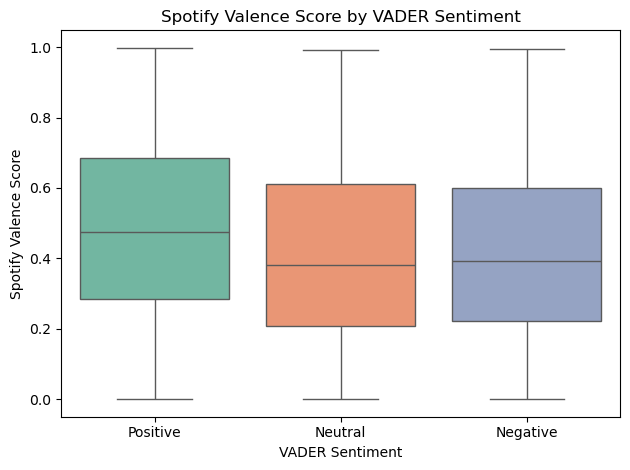

Saved songs_with_vader.csv


In [41]:
# Sanity check: Positive songs should have higher Spotify valence
sns.boxplot(data=songs_df, x='vader_sentiment', y='valence',
            order=['Positive', 'Neutral', 'Negative'],
            palette='Set2')
plt.title('Spotify Valence Score by VADER Sentiment')
plt.xlabel('VADER Sentiment')
plt.ylabel('Spotify Valence Score')
plt.tight_layout()
plt.show()

songs_df.to_csv("songs_with_vader.csv", index=False)
print("Saved songs_with_vader.csv")

## Feature Engineering — NRC Emotions

In [42]:
def nrc_features(text):
    try:
        text = str(text).replace('\\n', ' ').replace('\n', ' ')
        emotion = NRCLex()
        emotion.load_raw_text(text[:1000])
        scores = emotion.affect_frequencies
        return {
            'nrc_joy'         : scores.get('joy', 0),
            'nrc_sadness'     : scores.get('sadness', 0),
            'nrc_anger'       : scores.get('anger', 0),
            'nrc_fear'        : scores.get('fear', 0),
            'nrc_positive'    : scores.get('positive', 0),
            'nrc_negative'    : scores.get('negative', 0),
            'nrc_anticipation': scores.get('anticipation', 0),
            'nrc_trust'       : scores.get('trust', 0),
            'nrc_surprise'    : scores.get('surprise', 0),
            'nrc_disgust'     : scores.get('disgust', 0)
        }
    except:
        return {
            'nrc_joy': 0, 'nrc_sadness': 0, 'nrc_anger': 0,
            'nrc_fear': 0, 'nrc_positive': 0, 'nrc_negative': 0,
            'nrc_anticipation': 0, 'nrc_trust': 0,
            'nrc_surprise': 0, 'nrc_disgust': 0
        }

print("Running NRC on full dataset...")
nrc_df = songs_df['lyrics_normalized'].apply(nrc_features).apply(pd.Series)
songs_df = pd.concat([songs_df, nrc_df], axis=1)

print("Done!")
songs_df.to_csv("songs_with_NRC.csv", index=False)
print("Saved songs_with_NRC.csv")

Running NRC on full dataset...
Done!
Saved songs_with_NRC.csv


## Feature Engineering — VAD Scores

In [43]:
vad_df = pd.read_csv("NRC-VAD-Lexicon.txt", sep='\t',
                     names=['word', 'valence', 'arousal', 'dominance'])
print("VAD lexicon loaded:", len(vad_df), "words")

# Convert to dict once for fast lookup
vad_dict = vad_df.set_index('word')[['valence', 'arousal', 'dominance']].to_dict('index')
print("VAD dictionary size:", len(vad_dict))

def get_vad_scores_fast(text):
    try:
        text = str(text).replace('\\n', ' ').replace('\n', ' ')
        words = text.lower().split()
        scores = [vad_dict[word] for word in words if word in vad_dict]
        if len(scores) == 0:
            return {'vad_valence': 0, 'vad_arousal': 0, 'vad_dominance': 0}
        arr = np.array([[s['valence'], s['arousal'], s['dominance']] for s in scores])
        means = arr.mean(axis=0)
        return {
            'vad_valence'  : means[0],
            'vad_arousal'  : means[1],
            'vad_dominance': means[2]
        }
    except:
        return {'vad_valence': 0, 'vad_arousal': 0, 'vad_dominance': 0}

print("Running VAD on full dataset...")
vad_results = Parallel(n_jobs=-1)(
    delayed(get_vad_scores_fast)(text) for text in songs_df['lyrics_normalized']
)

vad_df_results = pd.DataFrame(vad_results)
songs_df = pd.concat([songs_df, vad_df_results], axis=1)

print("Done!")
print(songs_df[['vad_valence', 'vad_arousal', 'vad_dominance']].describe())

songs_df.to_csv("songs_with_NRC_VAD.csv", index=False)
print("Saved songs_with_NRC_VAD.csv")

VAD lexicon loaded: 19971 words
VAD dictionary size: 19971
Running VAD on full dataset...
Done!
         vad_valence    vad_arousal  vad_dominance
count  518538.000000  518538.000000  518538.000000
mean        0.594351       0.446318       0.501688
std         0.071329       0.049724       0.044927
min         0.000000       0.000000       0.000000
25%         0.550691       0.413719       0.473533
50%         0.595514       0.443161       0.500028
75%         0.639857       0.475077       0.528222
max         1.000000       0.931000       0.862469
Saved songs_with_NRC_VAD.csv


## Feature Engineering — Repetition, Negation, Exclamation

In [30]:
def repetition_ratio(text):
    lines = str(text).replace('\\n', '\n').split('\n')
    lines = [l.strip() for l in lines if l.strip() != '']
    if len(lines) == 0:
        return 0
    return 1 - (len(set(lines)) / len(lines))

negation_words = {'not', 'never', 'no', 'nobody', 'nothing',
                  'neither', 'nowhere', "don't", "won't", "can't",
                  "didn't", "doesn't", "isn't", "aren't", "wasn't"}

def negation_count(text):
    words = str(text).lower().replace('\\n', ' ').split()
    if len(words) == 0:
        return 0
    return sum(1 for word in words if word in negation_words) / len(words)

def exclamation_ratio(text):
    text = str(text)
    words = text.split()
    if len(words) == 0:
        return 0
    return text.count('!') / len(words)

songs_df['repetition_ratio']  = songs_df['lyrics_normalized'].apply(repetition_ratio)
songs_df['negation_count']    = songs_df['lyrics_normalized'].apply(negation_count)
songs_df['exclamation_ratio'] = songs_df['lyrics_normalized'].apply(exclamation_ratio)

print(songs_df[['repetition_ratio', 'negation_count', 'exclamation_ratio']].describe())

       repetition_ratio  negation_count  exclamation_ratio
count          518538.0   518538.000000      518538.000000
mean                0.0        0.024369           0.002144
std                 0.0        0.023520           0.009991
min                 0.0        0.000000           0.000000
25%                 0.0        0.007874           0.000000
50%                 0.0        0.018957           0.000000
75%                 0.0        0.034188           0.000000
max                 0.0        0.517857           0.545752


## KMeans Emotion Clustering (K=4)

In [10]:
# 9 features: 3 Spotify audio + 6 NRC

feature_columns = [
    'valence', 'energy', 'danceability',
    'nrc_joy', 'nrc_sadness', 'nrc_anger', 'nrc_fear',
    'nrc_positive', 'nrc_negative'
]

cluster_df = songs_df[feature_columns].dropna()
print("Songs for clustering:", len(cluster_df))

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(cluster_df)
print("Feature matrix shape:", X_scaled.shape)

Songs for clustering: 518538
Feature matrix shape: (518538, 9)


Testing k=2...
  Silhouette score: 0.221
Testing k=3...
  Silhouette score: 0.156
Testing k=4...
  Silhouette score: 0.153
Testing k=5...
  Silhouette score: 0.141
Testing k=6...
  Silhouette score: 0.129
Testing k=7...
  Silhouette score: 0.136
Testing k=8...
  Silhouette score: 0.135
Testing k=9...
  Silhouette score: 0.129
Testing k=10...
  Silhouette score: 0.130


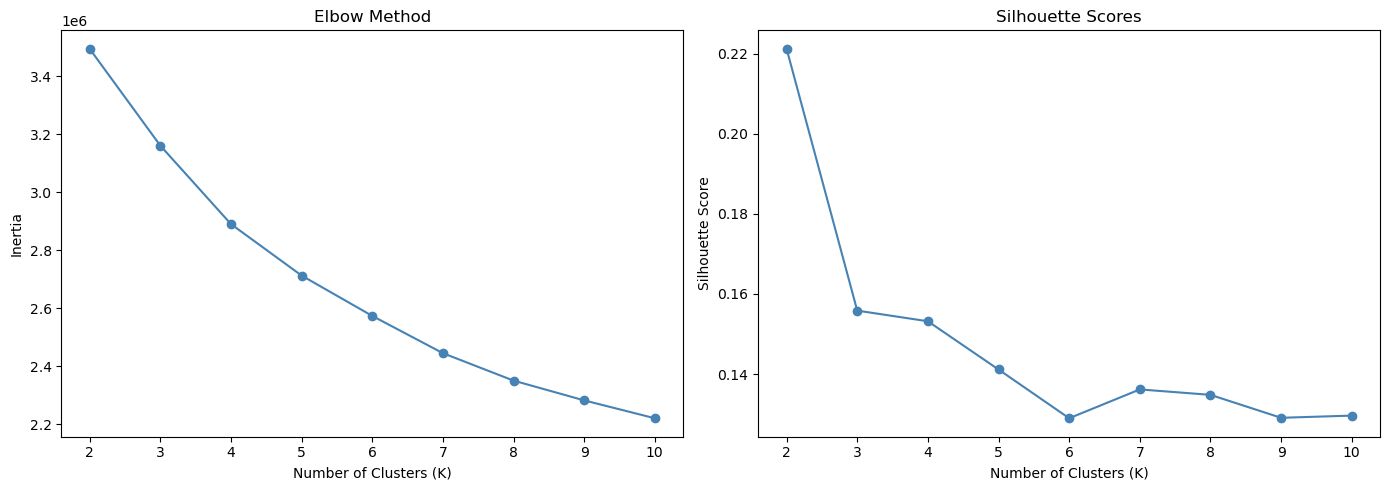


Best K by silhouette: 2


In [11]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    print(f"Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels, sample_size=10000)
    silhouette_scores.append(score)
    print(f"  Silhouette score: {score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_scores, marker='o', color='steelblue')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()
print("\nBest K by silhouette:", k_range[np.argmax(silhouette_scores)])

In [12]:
# Use K=4 for interpretability (Happy, Sad, Angry, Energetic)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
songs_df['cluster_raw'] = kmeans_final.fit_predict(X_scaled)

# Name clusters by valence ordering
cluster_valence = songs_df.groupby('cluster_raw')['valence'].mean().sort_values(ascending=False)
print("Cluster valence means:")
print(cluster_valence)

cluster_name_map = {}
sorted_clusters = cluster_valence.index.tolist()
cluster_name_map[sorted_clusters[0]] = 'Happy'
cluster_name_map[sorted_clusters[1]] = 'Energetic'
cluster_name_map[sorted_clusters[2]] = 'Sad'
cluster_name_map[sorted_clusters[3]] = 'Angry'

songs_df['emotion_cluster'] = songs_df['cluster_raw'].map(cluster_name_map)
print("\nCluster distribution:")
print(songs_df['emotion_cluster'].value_counts())

songs_df.to_csv("songs_with_clusters.csv", index=False)
print("Saved songs_with_clusters.csv")

Cluster valence means:
cluster_raw
0    0.659035
2    0.596557
3    0.325560
1    0.283985
Name: valence, dtype: float64

Cluster distribution:
emotion_cluster
Happy        142998
Sad          139686
Angry        130577
Energetic    105277
Name: count, dtype: int64
Saved songs_with_clusters.csv


## Supervised Classification — Feature Matrix
> TF-IDF uses `lyrics_normalized` directly (no separate tokenization needed).

In [28]:
# Load checkpoint if starting fresh
songs_df = pd.read_csv("songs_with_NRC_VAD.csv")

tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.95
)

X_tfidf = tfidf_vectorizer.fit_transform(songs_df['lyrics_normalized'])
print("TF-IDF shape:", X_tfidf.shape)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("Saved tfidf_vectorizer.pkl")

TF-IDF shape: (518538, 30000)
Saved tfidf_vectorizer.pkl


In [36]:
dense_feature_columns = [
    'valence', 'energy', 'danceability',
    'nrc_joy', 'nrc_sadness', 'nrc_anger', 'nrc_fear',
    'nrc_positive', 'nrc_negative', 'nrc_anticipation',
    'nrc_trust', 'nrc_surprise', 'nrc_disgust',
    'repetition_ratio', 'negation_count', 'exclamation_ratio',
    'vad_valence', 'vad_arousal', 'vad_dominance'
]

scaler = StandardScaler()
X_dense = scaler.fit_transform(songs_df[dense_feature_columns].fillna(0))
X_dense_sparse = csr_matrix(X_dense)

X_combined = hstack([X_tfidf, X_dense_sparse])
print("Combined matrix shape:", X_combined.shape)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved scaler.pkl")

songs_df.to_csv("songs_ready_for_classifier.csv", index=False)
sp.save_npz("X_combined.npz", X_combined)
print("All saved!")
print("\nFeature matrix shape:", X_combined.shape)
print("Dense features:", len(dense_feature_columns))

Combined matrix shape: (518538, 30019)
Saved scaler.pkl
All saved!

Feature matrix shape: (518538, 30019)
Dense features: 19


## LLM Annotation (Groq llama-3.3-70b-versatile)

In [32]:
import random
random.seed(42)
import pandas as pd
# Sample 850 songs per genre
songs_df = pd.read_csv("songs_ready_for_classifier.csv")  # Load the cleaned dataset
samples = []
for genre in songs_df['genre'].unique():
    subset = songs_df[songs_df['genre'] == genre]
    n = min(2050, len(subset))
    sampled = subset.sample(n=n, random_state=42)
    samples.append(sampled)

llm_sample = pd.concat(samples).reset_index(drop=True)
llm_sample = llm_sample[['id', 'name', 'artists', 'genre', 'popularity', 'lyrics_normalized']]

print("Total songs to annotate:", len(llm_sample))
print("Songs per genre:")
print(llm_sample['genre'].value_counts())

llm_sample.to_csv("llm_annotation_sample.csv", index=False)
print("Saved llm_annotation_sample.csv")

Total songs to annotate: 20500
Songs per genre:
genre
Rock          2050
Hip-Hop       2050
Classical     2050
Pop           2050
Jazz          2050
R&B           2050
Blues         2050
Electronic    2050
Country       2050
Folk          2050
Name: count, dtype: int64
Saved llm_annotation_sample.csv


In [ ]:
from groq import Groq

client = Groq(api_key="")

def label_batch(batch_df):
    songs_text = ""
    for idx, row in batch_df.iterrows():
        songs_text += f"""
Song {idx+1}:
Name: {row['name']}
Genre: {row['genre']}
Lyrics: {str(row['lyrics_normalized'])[:300]}
---"""

    prompt = f"""Classify each song into exactly one emotion.

Emotion definitions:
- Happy: Joyful, celebratory, feel-good, upbeat, positive
- Sad: Genuine grief, loss, crying, depression, pain
- Angry: Aggressive, frustrated, confrontational, revenge
- Energetic: Hype, party, dancing, motivational, excitement
- Romantic: Love, affection, intimacy, longing for a person
- Nostalgia: Missing the past, memories, reminiscing, bittersweet

Critical rules:
- Nostalgia is NOT Sad — remembering the past = Nostalgia
- Energetic is NOT Happy — party/hype songs = Energetic
- Only use Sad for genuine grief, loss, depression
- Hip-Hop = usually Energetic or Angry
- Love songs = Romantic not Happy
- Songs about the past = Nostalgia not Sad

Reply ONLY in this exact format:
Song 1 | Emotion: Romantic
Song 2 | Emotion: Energetic

Songs:
{songs_text}"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

def parse_labels(response_text, batch_size):
    labels = []
    lines = response_text.strip().split('\n')
    for line in lines:
        line = line.strip()
        if '|' in line and 'Emotion:' in line:
            try:
                emotion = line.split('Emotion:')[1].strip()
                emotion = emotion.split()[0].strip()
                labels.append(emotion)
            except:
                labels.append('Unknown')
    while len(labels) < batch_size:
        labels.append('Unknown')
    return labels[:batch_size]

In [34]:
# Run annotation — resumes from unlabeled songs if re-run
# Load existing progress if available
import pandas as pd
import time
llm_sample = pd.read_csv("llm_annotation_sample.csv")   
BATCH_SIZE = 50
all_labels = []

total_batches = len(llm_sample) // BATCH_SIZE + 1

for i in range(0, len(llm_sample), BATCH_SIZE):
    batch = llm_sample.iloc[i:i+BATCH_SIZE].reset_index(drop=True)
    batch_num = i // BATCH_SIZE + 1
    
    print(f"Processing batch {batch_num}/{total_batches}...")
    
    try:
        response = label_batch(batch)
        labels = parse_labels(response, len(batch))
        all_labels.extend(labels)
        
        # Small delay to avoid rate limiting
        time.sleep(1)
        
    except Exception as e:
        print(f"Error on batch {batch_num}: {e}")
        # Fill with Unknown on error
        all_labels.extend(['Unknown'] * len(batch))

print("Total labels:", len(all_labels))
print("Done!")



Processing batch 1/411...
Processing batch 2/411...
Processing batch 3/411...
Processing batch 4/411...
Processing batch 5/411...
Processing batch 6/411...
Processing batch 7/411...
Processing batch 8/411...
Processing batch 9/411...
Processing batch 10/411...
Processing batch 11/411...
Processing batch 12/411...
Processing batch 13/411...
Processing batch 14/411...
Processing batch 15/411...
Processing batch 16/411...
Processing batch 17/411...
Processing batch 18/411...
Processing batch 19/411...
Processing batch 20/411...
Processing batch 21/411...
Processing batch 22/411...
Processing batch 23/411...
Processing batch 24/411...
Processing batch 25/411...
Processing batch 26/411...
Processing batch 27/411...
Processing batch 28/411...
Processing batch 29/411...
Processing batch 30/411...
Processing batch 31/411...
Processing batch 32/411...
Processing batch 33/411...
Processing batch 34/411...
Processing batch 35/411...
Processing batch 36/411...
Processing batch 37/411...
Processing

In [35]:
llm_sample['emotion_label'] = all_labels

# Check label distribution
print("Label distribution:")
print(llm_sample['emotion_label'].value_counts())

# Check for unknowns
print("\nUnknown labels:", (llm_sample['emotion_label'] == 'Unknown').sum())

# Save
llm_sample.to_csv("llm_annotated_8500.csv", index=False)
print("Saved llm_annotated_8500.csv")

Label distribution:
emotion_label
Romantic     5882
Sad          4046
Energetic    3339
Angry        2406
Nostalgia    2277
Happy        1500
Unknown      1050
Name: count, dtype: int64

Unknown labels: 1050
Saved llm_annotated_8500.csv


In [37]:
llm_sample = pd.read_csv("llm_annotated_8500.csv")
llm_annotated = llm_sample[llm_sample['emotion_label'] != 'Unknown']

print("Clean labeled songs:", len(llm_annotated))
print(llm_annotated['emotion_label'].value_counts())

Clean labeled songs: 19450
emotion_label
Romantic     5882
Sad          4046
Energetic    3339
Angry        2406
Nostalgia    2277
Happy        1500
Name: count, dtype: int64


## Supervised Classifier (LR + SVM)

In [2]:
# Load from saved checkpoints
import pandas as pd
import scipy.sparse as sp
songs_df = pd.read_csv("songs_ready_for_classifier.csv")
X_combined = sp.load_npz("X_combined.npz")

labeled_df = pd.read_csv("llm_annotated_8500.csv")
# Drop invalid labels
labeled_df = labeled_df[labeled_df['emotion_label'].isin(['Happy', 'Sad', 'Angry', 'Romantic'])].copy()

print("Songs in full dataset:", len(songs_df))
print("Feature matrix shape:", X_combined.shape)
print("Labeled songs:", len(labeled_df))
print("\nLabel distribution:")
print(labeled_df['emotion_label'].value_counts())

Songs in full dataset: 518538
Feature matrix shape: (518538, 30019)
Labeled songs: 13834

Label distribution:
emotion_label
Romantic    5882
Sad         4046
Angry       2406
Happy       1500
Name: count, dtype: int64


In [3]:
# Match labeled songs back to full songs_df using id key

key_to_idx = {key: idx for idx, key in enumerate(songs_df['id'])}
labeled_df['songs_df_idx'] = labeled_df['id'].map(key_to_idx)

print("Total labeled songs:", len(labeled_df))
print("Successfully matched:", labeled_df['songs_df_idx'].notna().sum())
print("Failed to match:", labeled_df['songs_df_idx'].isna().sum())

labeled_df = labeled_df.dropna(subset=['songs_df_idx'])
matched_indices = labeled_df['songs_df_idx'].astype(int).values
X_labeled = X_combined[matched_indices]
y_labeled = labeled_df['emotion_label'].values

print("\nX_labeled shape:", X_labeled.shape)
print("y_labeled shape:", y_labeled.shape)

Total labeled songs: 13834
Successfully matched: 13834
Failed to match: 0

X_labeled shape: (13834, 30019)
y_labeled shape: (13834,)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_labeled, y_labeled,
    test_size=0.2,
    random_state=42,
    stratify=y_labeled
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, "—", len(y_train), "songs")
print("Val:  ", X_val.shape,   "—", len(y_val),   "songs")
print("Test: ", X_test.shape,  "—", len(y_test),  "songs")

Train: (11067, 30019) — 11067 songs
Val:   (1383, 30019) — 1383 songs
Test:  (1384, 30019) — 1384 songs


Training Logistic Regression...

=== Logistic Regression Validation ===
              precision    recall  f1-score   support

       Angry       0.64      0.73      0.68       241
       Happy       0.51      0.65      0.57       150
    Romantic       0.79      0.68      0.73       588
         Sad       0.65      0.67      0.66       404

    accuracy                           0.68      1383
   macro avg       0.65      0.68      0.66      1383
weighted avg       0.69      0.68      0.68      1383

Training Linear SVM...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== SVM Validation ===
              precision    recall  f1-score   support

       Angry       0.66      0.72      0.69       241
       Happy       0.61      0.52      0.56       150
    Romantic       0.77      0.75      0.76       588
         Sad       0.66      0.68      0.67       404

    accuracy                           0.70      1383
   macro avg       0.67      0.67      0.67      1383
weighted avg       0.70      0.70      0.70      1383


LR Macro F1:  0.661
SVM Macro F1: 0.670

Best model: SVM

=== SVM Final Test Results ===
              precision    recall  f1-score   support

       Angry       0.66      0.72      0.69       240
       Happy       0.61      0.58      0.59       150
    Romantic       0.78      0.78      0.78       589
         Sad       0.69      0.67      0.68       405

    accuracy                           0.71      1384
   macro avg       0.69      0.69      0.69      1384
weighted avg       0.71      0.71      0.71      1384



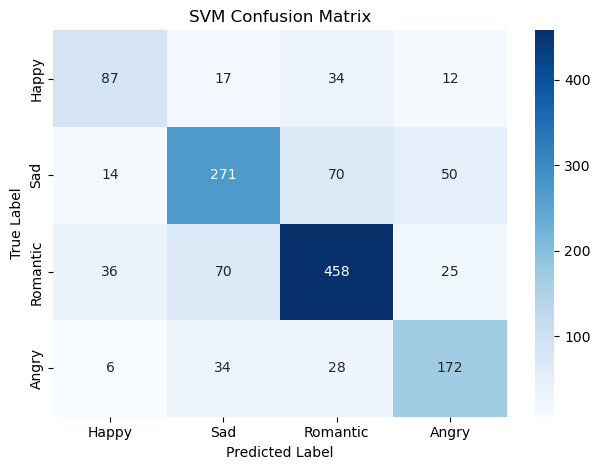

In [7]:
def run_classifier(X_train, X_val, X_test, y_train, y_val, y_test):
    print("Training Logistic Regression...")
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(X_train, y_train)
    lr_val_pred = lr.predict(X_val)
    print("\n=== Logistic Regression Validation ===")
    print(classification_report(y_val, lr_val_pred))

    print("Training Linear SVM...")
    svm = LinearSVC(max_iter=3000, random_state=42, class_weight='balanced')
    svm.fit(X_train, y_train)
    svm_val_pred = svm.predict(X_val)
    print("\n=== SVM Validation ===")
    print(classification_report(y_val, svm_val_pred))

    lr_f1  = classification_report(y_val, lr_val_pred,  output_dict=True)['macro avg']['f1-score']
    svm_f1 = classification_report(y_val, svm_val_pred, output_dict=True)['macro avg']['f1-score']

    print(f"\nLR Macro F1:  {lr_f1:.3f}")
    print(f"SVM Macro F1: {svm_f1:.3f}")

    best_model = lr if lr_f1 > svm_f1 else svm
    best_name  = "Logistic Regression" if lr_f1 > svm_f1 else "SVM"
    print(f"\nBest model: {best_name}")

    test_pred = best_model.predict(X_test)
    print(f"\n=== {best_name} Final Test Results ===")
    print(classification_report(y_test, test_pred))

    labels = ['Happy', 'Sad', 'Romantic', 'Angry']
    cm = confusion_matrix(y_test, test_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title(f'{best_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return best_model

best_model = run_classifier(X_train, X_val, X_test, y_train, y_val, y_test)